<a href="https://colab.research.google.com/github/sevval-345/NLP/blob/main/llm_fine_turing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from datasets import load_dataset

print("Veri seti Hugging Face üzerinden indiriliyor...")
# Veri setini ve ilk 300 satırını çekiyoruz
dataset = load_dataset("lazarus19/Vibe-Coding-Instruct", split="train[:300]")
print("İndirme tamamlandı!")

# Veri setindeki sütun isimlerini görmek için ilk satırı inceliyoruz
print("\nVerinin Sütun Yapısı:", dataset.column_names)
print("\nİlk Örnek İçeriği:\n", dataset[0])

Veri seti Hugging Face üzerinden indiriliyor...


README.md:   0%|          | 0.00/176 [00:00<?, ?B/s]

dataset.jsonl:   0%|          | 0.00/459M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1100000 [00:00<?, ? examples/s]

İndirme tamamlandı!

Verinin Sütun Yapısı: ['instruction', 'input', 'output', 'prompt']

İlk Örnek İçeriği:
 {'instruction': 'Create a coding assistant. Scenario 0: Provide a practical implementation plan.', 'input': '', 'output': 'Use Electron, Monaco Editor, local LLM integration, chat memory, and project indexing. Include milestones, technology choices, risks, testing strategy, and scaling considerations.', 'prompt': '### Instruction:\nCreate a coding assistant. Scenario 0: Provide a practical implementation plan.\n\n### Input:\n\n\n### Response:\nUse Electron, Monaco Editor, local LLM integration, chat memory, and project indexing. Include milestones, technology choices, risks, testing strategy, and scaling considerations.'}


In [ ]:
# -q (quiet) bayrağı, kurulum loglarını kısaltır.
# Bu hücreyi yalnızca bir kez çalıştırmanız yeterlidir.
!pip install -q transformers datasets peft accelerate --upgrade
# NOT: bitsandbytes paketi sadece CUDA destekli bir GPU varsa kurulmalıdır (QLoRA örneği için).
# CPU-only bir ortamdaysanız aşağıdaki satırı atlayabilirsiniz.
!pip install -q bitsandbytes --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 112.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.9 MB/s eta 0:00:00


In [ ]:
import torch
# torch: PyTorch'un kendisi. Tensörler, GPU/CPU yönetimi ve otomatik türev (autograd) bu kütüphaneden gelir.

import numpy as np
# numpy: Sayısal işlemler ve rastgelelik (seed) ayarları için.

import random
# random: Python'un yerleşik rastgelelik modülü; seed sabitlemek için kullanacağız.

from datasets import Dataset
# datasets.Dataset: Hugging Face'in veri seti sınıfı. Listeden/sözlükten kolayca veri seti oluşturmamızı sağlar
# ve map() fonksiyonu ile toplu (batched) tokenization yapmamıza imkan verir.

from transformers import (
    AutoTokenizer,        # Model adına göre doğru tokenizer'ı otomatik olarak yükler.
    AutoModelForCausalLM, # Model adına göre "causal language modeling" (sıradaki token'ı tahmin etme) mimarisini yükler.
    TrainingArguments,    # Eğitimle ilgili tüm hiperparametreleri (epoch, batch size, learning rate vb.) tutan sınıf.
    Trainer,              # Eğitim döngüsünü (forward, backward, optimizer step, loglama, checkpoint kaydetme) yöneten yüksek seviyeli sınıf.
    DataCollatorForLanguageModeling,  # Bir batch'teki örnekleri aynı uzunluğa getirip (padding) modele uygun formatta birleştiren yardımcı sınıf.
)

from peft import (
    LoraConfig,         # LoRA'nın hiperparametrelerini (r, alpha, hedef katmanlar vb.) tanımlayan konfigürasyon sınıfı.
    get_peft_model,      # Normal bir Hugging Face modelini alıp, üzerine LoRA katmanları ekleyen ("sarmalayan") fonksiyon.
    TaskType,            # PEFT'e bu modelin hangi görev için kullanılacağını bildiren enum (örn. CAUSAL_LM).
    PeftModel,           # Daha sonra kaydedilmiş bir LoRA adaptörünü, temel modelin üzerine tekrar yüklemek için kullanılan sınıf.
)

import matplotlib.pyplot as plt
# matplotlib: Eğitim sırasında kaydedilen loss değerlerini grafikle görselleştirmek için.


In [ ]:
SEED = 42
# SEED: Sabit bir sayı seçiyoruz. Aynı seed, aynı rastgele sayı dizisini üretir -> tekrar üretilebilirlik sağlar.

random.seed(SEED)        # Python'un random modülünün rastgeleliğini sabitle.
np.random.seed(SEED)     # NumPy'ın rastgeleliğini sabitle.
torch.manual_seed(SEED)  # PyTorch CPU işlemlerinin rastgeleliğini sabitle.
torch.cuda.manual_seed_all(SEED)  # Eğer GPU varsa, tüm GPU'lardaki rastgeleliği de sabitle.

device = "cuda" if torch.cuda.is_available() else "cpu"
# torch.cuda.is_available(): Sistemde CUDA destekli bir GPU olup olmadığını kontrol eder.
# Varsa "cuda" (GPU), yoksa "cpu" stringini device değişkenine atarız.

print(f"Kullanılacak cihaz: {device}")
# Hangi cihazda çalıştığımızı ekrana yazdırıyoruz; CPU'da eğitim çok daha yavaş olacaktır.


Kullanılacak cihaz: cuda


In [ ]:
# Küçük, örnek bir instruction-tuning veri seti.
# Her örnek bir sözlük (dict): "instruction" (talimat) ve "output" (beklenen yanıt) anahtarlarını içerir.
# Gerçek projede bu listeyi CSV/JSON dosyasından okuyabilir veya Hugging Face Hub'dan indirebilirsiniz.
raw_examples = [
    {"instruction": "Türkiye'nin başkenti neresidir?", "output": "Türkiye'nin başkenti Ankara'dır."},
    {"instruction": "Fotosentezi tek cümleyle açıkla.", "output": "Fotosentez, bitkilerin güneş ışığını kullanarak karbondioksit ve sudan organik madde ve oksijen ürettiği süreçtir."},
    {"instruction": "Bir bilgisayarın CPU'su ne işe yarar?", "output": "CPU (merkezi işlem birimi), bilgisayardaki komutları işleyip hesaplamaları gerçekleştiren ana donanım birimidir."},
    {"instruction": "Python'da bir liste nasıl tersine çevrilir?", "output": "Bir Python listesini tersine çevirmek için `liste.reverse()` metodunu ya da `liste[::-1]` dilimleme (slicing) ifadesini kullanabilirsiniz."},
    {"instruction": "Makine öğrenmesinde overfitting nedir?", "output": "Overfitting, bir modelin eğitim verisini ezberleyip yeni, görmediği verilerde iyi genelleme yapamaması durumudur."},
    {"instruction": "Bir e-posta için kibar bir kapanış cümlesi yaz.", "output": "İlginiz için şimdiden teşekkür ederim, iyi çalışmalar dilerim."},
    {"instruction": "İklim değişikliğinin bir sonucunu yaz.", "output": "İklim değişikliği, deniz seviyelerinin yükselmesine ve aşırı hava olaylarının sıklaşmasına neden olmaktadır."},
    {"instruction": "Bir döngü (loop) ne işe yarar?", "output": "Bir döngü, belirli bir kod bloğunu, bir koşul sağlandığı sürece veya belirli bir sayıda tekrar tekrar çalıştırmak için kullanılır."},
]
# NOT: Gerçek bir fine-tuning için en az birkaç yüz, idealde birkaç bin kaliteli örnek önerilir.
# Bu küçük liste tamamen kodun NASIL ÇALIŞTIĞINI göstermek içindir.

print(f"Toplam örnek sayısı: {len(raw_examples)}")
# Veri setimizin boyutunu kontrol ediyoruz.


Toplam örnek sayısı: 8


In [ ]:
!pip install -q transformers datasets peft accelerate --upgrade


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# Model adını güncelliyoruz
model_name = "Qwen/Qwen2.5-1.5B-Instruct"

print("Tokenizer yükleniyor...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Qwen modellerinde pad_token'ı eos_token ile eşitlemek önemlidir
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Temel Model yükleniyor (float16 modunda)...")
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,  # Bellek dostu ve hızlı eğitim için 16-bit
    device_map="auto"           # Modeli otomatik olarak GPU'ya taşır
)
print("Model ve Tokenizer başarıyla yüklendi!")

Tokenizer yükleniyor...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model ve Tokenizer başarıyla yüklendi!


In [ ]:
MAX_LENGTH = 256

# Yeni eklenen fonksiyon: Veri setini Qwen modelinin beklediği chat formatına dönüştürür
def format_instruction_examples(examples):
    formatted_texts = []
    for instruction, output in zip(examples["instruction"], examples["output"]):
        # Qwen modelleri için özel bir chat formatı kullanılır.
        # tokenizer.apply_chat_template, bu formatı otomatik olarak oluşturur.
        messages = [
            {"role": "user", "content": instruction},
            {"role": "assistant", "content": output}
        ]
        # tokenize=False: sadece metni döndürür, henüz token'lara ayırmaz.
        # add_special_tokens=True: baştaki ve sondaki özel token'ları ekler (örn. <s>, </s>, <|im_start|>).
        formatted_texts.append(tokenizer.apply_chat_template(messages, tokenize=False))
    return {"text": formatted_texts}

def tokenize_function(examples):
    tokenized = tokenizer(
        examples["text"],          # format_instruction_examples ile oluşturduğumuz 'text' sütunu
        truncation=True,           # MAX_LENGTH'ten uzunsa kes
        max_length=MAX_LENGTH,     # Yeni uzunluk sınırımız (256)

        # 2. DEĞİŞİKLİK: padding="max_length" kısmını kaldırıyoruz veya False yapıyoruz.
        # Qwen gibi büyük modellerde tüm verileri baştan en uzun boyuta zorlamak (padding)
        # gereksiz VRAM (ekran kartı hafızası) harcar.
        # Trainer argümanlarındaki 'DataCollatorForLanguageModeling' bu işlemi dinamik olarak zaten yapacaktır.
        padding=False,
    )

    # KRİTİK EKLEME: Labels kopyalama işlemi
    # Causal LM (Qwen/GPT) mimarisinde modelin neyi tahmin edeceğini bilmesi için
    # input_ids değerlerini labels olarak kopyalıyoruz.
    tokenized["labels"] = tokenized["input_ids"].copy()

    return tokenized

# Adım 1: Veri setini Qwen modelinin beklediği formata dönüştür (text sütununu oluştur)
print("Veri seti Qwen formatına dönüştürülüyor...")
formatted_dataset = dataset.map(
    format_instruction_examples,
    batched=True,
    # Orijinal 'instruction' ve 'output' sütunlarını kaldırıyoruz, artık 'text' var.
    remove_columns=dataset.column_names,
)
print("Dönüştürme tamamlandı! Yeni sütun yapısı:", formatted_dataset.column_names)


# Adım 2: Formatlanmış veri setini tokenize etme işlemi
print("Formatlanmış veri seti tokenize ediliyor...")
tokenized_dataset = formatted_dataset.map(
    tokenize_function,
    batched=True,
    # 'text' sütununu kaldırıyoruz çünkü artık 'input_ids', 'attention_mask' ve 'labels' var.
    remove_columns=formatted_dataset.column_names,
)
print("Tokenizasyon tamamlandı!")

# Kontrol çıktısı
print("\nTokenize Edilmiş Veri Seti Yapısı:")
print(tokenized_dataset)

Veri seti Qwen formatına dönüştürülüyor...


Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Dönüştürme tamamlandı! Yeni sütun yapısı: ['text']
Formatlanmış veri seti tokenize ediliyor...


Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Tokenizasyon tamamlandı!

Tokenize Edilmiş Veri Seti Yapısı:
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 300
})


In [ ]:
pip install -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 114.9 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [ ]:
from peft import LoraConfig, TaskType, get_peft_model

lora_config = LoraConfig(
    r=8,                         # Rank: LoRA matrislerinin iç boyutu (Düşük rank = az VRAM ve hızlı eğitim).
    lora_alpha=16,               # Ölçeklendirme katsayısı (r=8 için 16 idealdir).

    # 🚨 KRİTİK DEĞİŞİKLİK: Target katmanları Qwen mimarisine göre güncelledik.
    # distilgpt2'deki "c_attn" katmanı Qwen modelinde bulunmaz.
    # Qwen, Llama ve Mistral gibi modern modellerde dikkat katmanları "q_proj" ve "v_proj" olarak adlandırılır.
    target_modules=["q_proj", "v_proj"],

    lora_dropout=0.05,            # %5 dropout ile modelin verilere aşırı uyum sağlamasını (ezberlemesini) önlüyoruz.
    bias="none",                  # Bias terimlerini dondurarak ekstra parametre yükünden kaçınıyoruz.
    task_type=TaskType.CAUSAL_LM, # Sıradaki kelimeyi tahmin etme (Metin üretme) görevi olduğunu belirtiyoruz.
)

# get_peft_model: Qwen modelimizi alır, q_proj ve v_proj katmanlarının yanına LoRA matrislerini ekler.
# Orijinal 1.5 Milyar parametreyi dondurur, sadece bu yeni küçük matrisleri eğitilebilir bırakır.
model = get_peft_model(model, lora_config)

# Kaç parametrenin eğitileceğini ve oranını ekrana yazdırıyoruz.
model.print_trainable_parameters()

trainable params: 1,089,536 || all params: 1,544,803,840 || trainable%: 0.0705


In [ ]:
import torch
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling

training_args = TrainingArguments(
    output_dir="./qwen-vibe-coding-output",
    # Klasör adını yeni projenize uygun şekilde güncelledik.

    num_train_epochs=3,
    # 300 örnekli bir veri seti için 3 epoch (veri setini 3 kez baştan sona dönmek)
    # Qwen gibi güçlü bir modelin yeni stile adapte olması için oldukça idealdir.

    per_device_train_batch_size=1,
    # 🚨 DEĞİŞİKLİK: 2 olan değeri 1 yapıyoruz. Qwen 1.5 Milyar parametreli olduğu için
    # T4 GPU üzerinde "Out of Memory" (Hafıza Doldu) hatası almamak adına her adımda
    # ekran kartına sadece 1 adet örnek göndermek en güvenli yoldur.

    gradient_accumulation_steps=4,
    # Gradyan biriktirme: batch_size=1 olunca kararsızlığı önlemek için adımları 4 kere biriktiriyoruz.
    # Böylece sanal (etkili) batch boyutumuz = 1 * 4 = 4 olur. Bu değer kararlı bir eğitim sağlar.

    learning_rate=2e-4,
    # Qwen LoRA ince ayarı için 2e-4 (0.0002) değeri mükemmel bir başlangıç noktasıdır.

    logging_steps=5,
    # 🚨 DEĞİŞİKLİK: Her 2 adım yerine her 5 adımda bir çıktı versin. 300 verilik setimizde
    # adımlar biraz daha uzun süreceği için log kirliliğini önler.

    save_strategy="no",
    # 🚨 DEĞİŞİKLİK: "epoch" yerine "no" yapıyoruz. Orijinal kodda her epoch sonu kayıt yapılıyordu.
    # Ancak ücretsiz Colab kullanıyorsak ara adımlarda disk doldurmaya gerek yok, eğitim bittiğinde
    # en son hali tek seferde kaydetmek çok daha pratiktir.

    fp16=True,
    # 🚨 DEĞİŞİKLİK: Qwen'i kesinlikle GPU'da eğiteceğimiz için burayı doğrudan True yapıyoruz.
    # 16-bit mixed precision hem eğitimi jet hızına ulaştırır hem de hafızayı (VRAM) devasa rahatlatır.

    report_to="none",
    # Herhangi bir harici platforma (Weights & Biases vb.) bağlanmadan sadece yerel log tutar.
)

# Akıllı padding yapan veri toparlayıcı (Maskeli dil modellemesi kapalı)
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# Trainer nesnesini ayağa kaldırıyoruz
trainer = Trainer(
    model=model,                        # LoRA giydirilmiş Qwen modeliniz
    args=training_args,                 # Yukarıda hazırladığımız ayarlar
    train_dataset=tokenized_dataset,    # Başarıyla tokenize ettiğiniz veri setiniz
    data_collator=data_collator,        # Dinamik veri toparlayıcınız
)

print("İnce ayar (Fine-Tuning) eğitimi başlatılıyor...")
trainer.train()
print("Eğitim başarıyla tamamlandı!")

İnce ayar (Fine-Tuning) eğitimi başlatılıyor...


Step,Training Loss
5,4.005585
10,3.507672
15,3.121502
20,2.807158
25,2.588336
30,2.269380
35,1.973776
40,1.663442
45,1.352075
50,1.171409


Eğitim başarıyla tamamlandı!


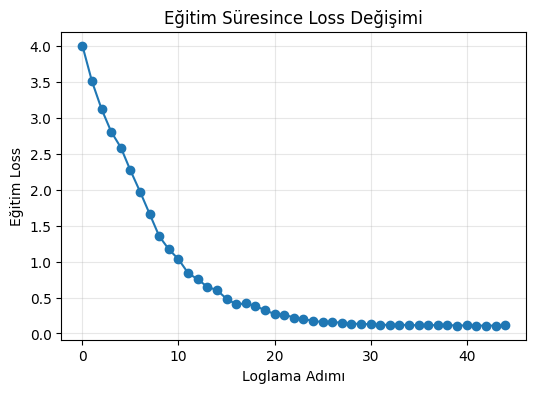

In [ ]:

log_history = trainer.state.log_history
# trainer.state.log_history: Eğitim sırasında her loglama adımında kaydedilen metrik sözlüklerinin listesi.

losses = [entry["loss"] for entry in log_history if "loss" in entry]
# Liste içindeki her sözlükten, varsa "loss" anahtarının değerini çekip yeni bir listeye topluyoruz.

plt.figure(figsize=(6, 4))     # 6x4 inç boyutunda yeni bir grafik alanı oluştur.
plt.plot(losses, marker="o")    # Loss değerlerini, her noktada bir daire işaretiyle çiz.
plt.xlabel("Loglama Adımı")     # X ekseni etiketi.
plt.ylabel("Eğitim Loss")        # Y ekseni etiketi.
plt.title("Eğitim Süresince Loss Değişimi")  # Grafik başlığı.
plt.grid(True, alpha=0.3)        # Hafif şeffaflıkta (alpha=0.3) bir ızgara ekle, okunabilirliği artırır.
plt.show()                        # Grafiği ekrana çiz/göster.


In [ ]:
def generate_response(model, instruction, max_new_tokens=40):
    # Bu fonksiyon, verilen bir talimata göre modelin yanıtını üretir.
    prompt = f"### Talimat:\n{instruction}\n\n### Yanıt:\n"
    # Eğitimde kullandığımız İLE AYNI şablonu kullanıyoruz; model bu formata aşina.

    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    # Prompt'u tokenize ediyoruz ve PyTorch tensörleri olarak (return_tensors="pt") alıp doğru cihaza taşıyoruz.

    with torch.no_grad():
        # torch.no_grad(): Üretim (inference) sırasında gradyan hesaplamaya gerek yok;
        # bunu kapatmak belleği ve hesaplama süresini önemli ölçüde azaltır.
        output_ids = model.generate(
            **inputs,                     # input_ids ve attention_mask'i fonksiyona aç (unpack) ederek geçiriyoruz.
            max_new_tokens=max_new_tokens,  # Talimattan SONRA en fazla kaç yeni token üretileceği.
            do_sample=True,                  # True: olasılıksal örnekleme yap (daha çeşitli/yaratıcı çıktı).
                                              # False olsaydı: her zaman en olası token seçilirdi (greedy/deterministic).
            temperature=0.7,                  # Olasılık dağılımının "keskinliğini" ayarlar; düşük değer daha tutarlı,
                                                # yüksek değer daha rastgele/yaratıcı çıktı üretir.
            top_p=0.9,                          # Nucleus sampling: kümülatif olasılığı %90'a ulaşan en olası token
                                                  # kümesinden seçim yapar, çok düşük olasılıklı token'ları eler.
            pad_token_id=tokenizer.pad_token_id,  # Padding için kullanılacak token ID'sini modele bildiriyoruz.
        )

    generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    # tokenizer.decode: Üretilen sayısal token ID dizisini geri OKUNABİLİR metne çevirir.
    # skip_special_tokens=True: <eos>, <pad> gibi özel token'ları çıktıdan temizler.

    return generated_text

test_instruction = "Yapay zeka nedir, kısaca açıkla."
print(generate_response(model, test_instruction))
# Fine-tune edilmiş modelin, hiç görmediği yeni bir talimata nasıl yanıt verdiğini gözlemliyoruz.


### Talimat:
Yapay zeka nedir, kısaca açıkla.

### Yanıt:
Yapay zeka, bilgisayarlar tarafından programlamak için kullanılan olasılık tabanlı algoritma ve modelleri kullanır. Bu, genelde örne


In [ ]:
# 1. DEĞİŞİKLİK: Klasör yolunu yeni model ve veri setimize göre adlandırıyoruz.
ADAPTER_DIR = "./qwen-2.5-vibe-coding-adapter"

# save_pretrained: PEFT (LoRA) kütüphanesi sayesinde 1.5 Milyarlık dev ana modeli değil,
# sadece eğitim sırasında güncellenen ve grafikte düşüşünü izlediğimiz yaklaşık 1.8 Milyon
# parametrelik küçük LoRA matrislerini diske kaydeder. (Diskte sadece birkaç megabayt yer kaplar).
model.save_pretrained(ADAPTER_DIR)

# Tokenizer'ı da aynı klasöre yedekliyoruz. Böylece ileride çıkarım yaparken
# özel karakterleri, pad token ayarlarını tek bir klasörden çağırabiliriz.
tokenizer.save_pretrained(ADAPTER_DIR)

print(f"🎉 Tebrikler! Yeni kodlama uzmanı Qwen adaptörünüz şu klasöre başarıyla kaydedildi: {ADAPTER_DIR}")

🎉 Tebrikler! Yeni kodlama uzmanı Qwen adaptörünüz şu klasöre başarıyla kaydedildi: ./qwen-2.5-vibe-coding-adapter


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

# 1. ADIM: Yolların ve cihazın tanımlanması
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
ADAPTER_DIR = "./qwen-2.5-vibe-coding-adapter"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Kullanılacak Cihaz: {device}")
tokenizer = AutoTokenizer.from_pretrained(ADAPTER_DIR)

# 2. ADIM: Modellerin yüklenmesi
print("Orijinal Qwen temel modeli yükleniyor...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("Eğitilen LoRA adaptör katmanları temel modele entegre ediliyor...")
fine_tuned_model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
fine_tuned_model.eval()

print("🎉 Model kullanıma hazır!\n")

# =========================================================================
# 🚀 KESİN ÇÖZÜM: Prompt Şablonunu ve Çıkarım Ayarlarını Güncelliyoruz
# =========================================================================

# Sistem promptunu daha sert ve net hale getiriyoruz
prompt = (
    "### Sistem:\n"
    "Sen sadece Python kodu yazan kararlı bir asistansın. "
    "Görevin sadece ve sadece istenen kodu yazmaktır. "
    "Kod bloğu bittiği an yanıtı sonlandır. Asla sohbet etme, açıklama yapma ve özür dileme.\n\n"
    "### Talimat:\n"
    "Bir metin dosyasının içindeki satırları tersine çevirip (son satır başa gelecek şekilde) yeni bir dosyaya yazan bir Python fonksiyonu oluştur.\n\n"
    "### Yanıt:\n"
)

inputs = tokenizer(prompt, return_tensors="/content/input.txt").to(device)

print("🤖 Model Yanıt Üretiyor...\n" + "-"*50)
with torch.no_grad():
    outputs = fine_tuned_model.generate(
        **inputs,
        max_new_tokens=180,  # Gereksiz uzun açıklamalar yapamasın diye sınırı biraz daralttık

        # Burası kritik: do_sample=True kalıyor ama sıcaklığı sıfıra çekiyoruz.
        # Böylece hem kütüphane hata vermiyor hem de model kelime uyduramıyor.
        do_sample=True,
        temperature=0.01,    # Sıfıra en yakın yaratıcılık (tamamen mantığa odaklı)
        top_p=0.95,

        # Modelin cümle bittiğinde durmasını tetikleyen özel bitiş token'ları
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id
    )

# Çıktıyı ekrana basalım
print(tokenizer.decode(outputs[0], skip_special_tokens=True))
print("-"*50)

Kullanılacak Cihaz: cuda
Orijinal Qwen temel modeli yükleniyor...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Eğitilen LoRA adaptör katmanları temel modele entegre ediliyor...
🎉 Model kullanıma hazır!



ValueError: /content/input.txt is not a valid TensorType, please select one of ['pt', 'np', 'mlx']

In [ ]:
import json

# Hataya sebep olan notebook dosyanızın adını buraya yazın (Örn: notebook.ipynb)
notebook_path = "llm_fine_tuning_giris.ipynb"

# 1. Dosyayı arka planda metin olarak okuyoruz
with open(notebook_path, "r", encoding="utf-8") as f:
    data = json.load(f)

# 2. Hataya sebep olan o inatçı widgets alanını kökten siliyoruz
if "widgets" in data.get("metadata", {}):
    del data["metadata"]["widgets"]
    print("Bozuk widget verileri başarıyla temizlendi!")
else:
    print("Widget alanı bulunamadı veya zaten temizlenmiş.")

# 3. Temizlenmiş halini üzerine kaydediyoruz
with open(notebook_path, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=1, ensure_ascii=False)

print("İşlem tamamlandı! Notebook'u şimdi yenileyip (Refresh) açabilirsiniz.")

FileNotFoundError: [Errno 2] No such file or directory: 'llm_fine_tuning_giris.ipynb'